In [2]:
!nvidia-smi

Tue Apr  7 16:06:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [4]:
%pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 11.6 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=12caaf4f7a321e65f3104445b3862adb7d9e98c66c801b8dcec3cfc7632262df
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


In [5]:
import numpy as np
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import time
import matplotlib.pyplot as plt

# CUDA-ядро для параллельной редукции (суммирование элементов вектора)


vector_sum_kernel = """
__global__ void addKernel(int* result, const int* a, unsigned int size) {
    // Динамически выделяемая shared-память (размер передаётся при запуске ядра)
    extern __shared__ int sharedSum[];

    unsigned int index = blockIdx.x * blockDim.x + threadIdx.x;
    int localSum = 0;

    // Каждый поток загружает свой элемент вектора (или 0, если индекс вне диапазона)
    if (index < size) {
        localSum = a[index];
    }

    // Записываем локальное значение в shared-память
    sharedSum[threadIdx.x] = localSum;
    __syncthreads();  // Барьер: все потоки блока загрузили данные

    // Редукция внутри блока: на каждом шаге stride уменьшается вдвое.
    // Активные потоки (threadIdx.x < stride) суммируют пары элементов.
    // Это минимизирует обращения к глобальной памяти и использует
    // быстрый shared-доступ.
    for (unsigned int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
        if (threadIdx.x < stride) {
            sharedSum[threadIdx.x] += sharedSum[threadIdx.x + stride];
        }
        __syncthreads();  // Барьер между шагами редукции
    }

    // Поток 0 каждого блока записывает сумму блока в глобальную память.
    // atomicAdd гарантирует корректное суммирование результатов разных блоков
    // без гонки данных.
    if (threadIdx.x == 0) {
        atomicAdd(result, sharedSum[0]);
    }
}
"""

# Компилируем ядро один раз — вне функции, чтобы не тратить время
# на компиляцию при каждом вызове vector_sum_gpu
_mod = SourceModule(vector_sum_kernel)
_cuda_kernel = _mod.get_function("addKernel")


def vector_sum_gpu(vector):
    """
    Суммирование элементов вектора на GPU (CUDA).

    Параллелизация:
      - Каждый CUDA-поток загружает один элемент вектора.
      - Внутри каждого блока выполняется редукция в shared-памяти
        за O(log(block_size)) шагов.
      - Частичные суммы блоков атомарно прибавляются к итоговому результату.

    :param vector: входной вектор (numpy array, dtype=int32)
    :return: (answer, elapsed_seconds)
    """
    block_size = 256
    grid_size = (len(vector) + block_size - 1) // block_size

    # Выделяем память на GPU и копируем данные
    vector_gpu = cuda.mem_alloc(vector.nbytes)
    result_gpu = cuda.mem_alloc(np.int32().nbytes)

    initial_value = np.array([0], dtype=np.int32)
    cuda.memcpy_htod(result_gpu, initial_value)
    cuda.memcpy_htod(vector_gpu, vector)

    start_time = time.time()

    # Запускаем ядро; третий аргумент — размер shared-памяти в байтах на блок
    _cuda_kernel(
        result_gpu,
        vector_gpu,
        np.uint32(len(vector)),
        block=(block_size, 1, 1),
        grid=(grid_size, 1),
        shared=block_size * np.dtype(np.int32).itemsize,  # динамический shared
    )

    # Ждём завершения всех GPU-потоков перед замером времени
    cuda.Context.synchronize()
    end_time = time.time()

    result = np.empty(1, dtype=np.int32)
    cuda.memcpy_dtoh(result, result_gpu)

    return int(result[0]), end_time - start_time


def vector_sum_cpu(vector):
    """
    Последовательное суммирование элементов вектора на CPU.
    Выполняется в одном потоке — каждый элемент добавляется
    по очереди, без какого-либо параллелизма.

    :param vector: входной вектор (numpy array, dtype=int32)
    :return: answer (int)
    """
    answer = 0
    for elem in vector:
        answer += int(elem)
    return answer


if __name__ == "__main__":
    vector_size = 500_000
    vector = np.random.randint(1, 10, size=vector_size, dtype=np.int32)

    # CPU
    start_time_cpu = time.time()
    answer_cpu = vector_sum_cpu(vector)
    time_cpu = time.time() - start_time_cpu

    print(f"Сумма на CPU: {answer_cpu}, Время: {time_cpu:.6f} сек")

    # GPU
    answer_gpu, time_gpu = vector_sum_gpu(vector)
    print(f"Сумма на GPU: {answer_gpu}, Время: {time_gpu:.6f} сек")

    assert answer_cpu == answer_gpu, "Результаты CPU и GPU не совпадают!"
    print("Результаты совпадают. ✓")

Сумма на CPU: 2500042, Время: 0.053540 сек
Сумма на GPU: 2500042, Время: 0.001159 сек
Результаты совпадают. ✓


## Эксперименты: сравнение времени CPU vs GPU

In [6]:
# Эксперименты для разных размеров вектора
sizes = [1_000, 50_000, 125_000, 250_000, 500_000, 1_000_000]

results = []

for size in sizes:
    vector = np.random.randint(1, 10, size=size, dtype=np.int32)

    # CPU
    t0 = time.time()
    ans_cpu = vector_sum_cpu(vector)
    t_cpu = time.time() - t0

    # GPU
    ans_gpu, t_gpu = vector_sum_gpu(vector)

    assert ans_cpu == ans_gpu, f"Ошибка при размере {size}!"

    speedup = t_cpu / t_gpu if t_gpu > 0 else float('inf')
    results.append((size, t_cpu, t_gpu, speedup))
    print(f"Размер: {size:>8} | CPU: {t_cpu:.6f} сек | GPU: {t_gpu:.6f} сек | Ускорение: {speedup:.2f}x")



Размер:     1000 | CPU: 0.000127 сек | GPU: 0.000096 сек | Ускорение: 1.31x
Размер:    50000 | CPU: 0.006396 сек | GPU: 0.000047 сек | Ускорение: 135.48x
Размер:   125000 | CPU: 0.013334 сек | GPU: 0.000063 сек | Ускорение: 210.26x
Размер:   250000 | CPU: 0.058821 сек | GPU: 0.000106 сек | Ускорение: 556.92x
Размер:   500000 | CPU: 0.138406 сек | GPU: 0.000133 сек | Ускорение: 1044.09x
Размер:  1000000 | CPU: 0.241668 сек | GPU: 0.000202 сек | Ускорение: 1196.73x


In [7]:
# Таблица результатов
print(f"{'Размер вектора':>16} | {'CPU (сек)':>12} | {'GPU (сек)':>12} | {'Ускорение':>12}")
print("-" * 62)
for size, t_cpu, t_gpu, speedup in results:
    print(f"{size:>16} | {t_cpu:>12.6f} | {t_gpu:>12.6f} | {speedup:>11.2f}x")

  Размер вектора |    CPU (сек) |    GPU (сек) |    Ускорение
--------------------------------------------------------------
            1000 |     0.000127 |     0.000096 |        1.31x
           50000 |     0.006396 |     0.000047 |      135.48x
          125000 |     0.013334 |     0.000063 |      210.26x
          250000 |     0.058821 |     0.000106 |      556.92x
          500000 |     0.138406 |     0.000133 |     1044.09x
         1000000 |     0.241668 |     0.000202 |     1196.73x


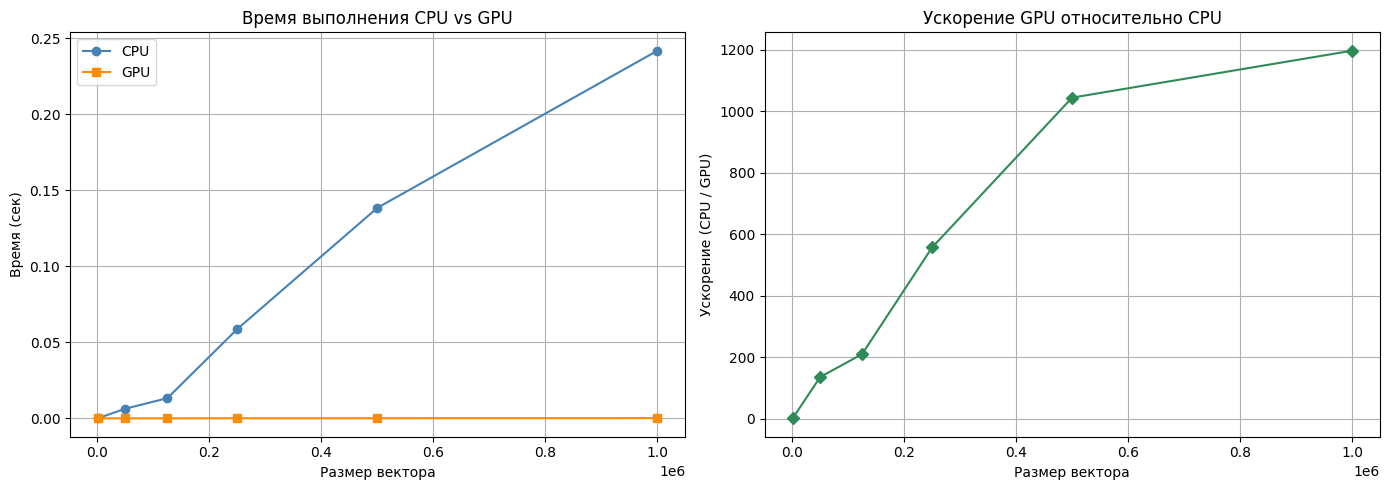

График сохранён как speedup_chart.png


In [8]:
# График ускорения
sizes_plot = [r[0] for r in results]
speedups   = [r[3] for r in results]
t_cpu_plot = [r[1] for r in results]
t_gpu_plot = [r[2] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Левый: время выполнения
ax1.plot(sizes_plot, t_cpu_plot, 'o-', label='CPU', color='steelblue')
ax1.plot(sizes_plot, t_gpu_plot, 's-', label='GPU', color='darkorange')
ax1.set_xlabel('Размер вектора')
ax1.set_ylabel('Время (сек)')
ax1.set_title('Время выполнения CPU vs GPU')
ax1.legend()
ax1.grid(True)

# Правый: ускорение
ax2.plot(sizes_plot, speedups, 'D-', color='seagreen')
ax2.set_xlabel('Размер вектора')
ax2.set_ylabel('Ускорение (CPU / GPU)')
ax2.set_title('Ускорение GPU относительно CPU')
ax2.grid(True)

plt.tight_layout()
plt.savefig('speedup_chart.png', dpi=150)
plt.show()
print("График сохранён как speedup_chart.png")